$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Data:}$ 12/07/2025

# Trabalho de Simulação

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import scipy.stats as stats
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.optimize import minimize
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

In [2]:
rng = np.random.default_rng(seed=4)

In [129]:
!pip install scikit-optimize

You should consider upgrading via the 'c:\users\aless\desktop\codes\venv3.9\scripts\python.exe -m pip install --upgrade pip' command.


# Exemplos

## AR
$ y_t = \phi y_{t-1} + \varepsilon_t,   \varepsilon_t \sim N(0, \sigma^2)
$ e $p(y_1) \sim N(a_1, P_1)
$

In [165]:
T = 100 # número de observações
ϕ, σ = 0.2, 3.5 # parâmetros reais

ϵt = rng.normal(0, σ, size=T)
y_true = np.zeros(T)

for t in range(1, T):
    y_true[t] = ϕ*y_true[t-1] + ϵt[t]

### Funções

In [134]:
def neg_log_likelihood(theta, y_true, N=1000):
    ϕ, σ = theta
    # ϕ, log_σ = theta
    # σ = np.exp(log_σ)
    a1, P1 = 0, σ**2/(1 - ϕ**2)
    T = len(y_true)
    
    ϵt = rng.normal(0, σ, size=(N,T))
    y1 = rng.normal(loc=a1, scale=np.sqrt(P1), size=N)
    
    yt = np.zeros((N,T))
    yt[:,0] = y1
    
    for t in range(1, T):
        yt[:,t] = ϕ*yt[:,t-1] + ϵt[:,t]
        
    yt_hat = np.mean(yt, axis=0) # média da densidade simulada
    Ft = np.mean(np.power(yt - yt_hat, 2), axis=0) # variância da densidade estimada
    vt = y_true - yt_hat # inovações
    
    log_likelihood = (
        -T/2 * np.log(2 * np.pi)
        -0.5 * np.sum(np.log(Ft) + np.power(vt, 2)/Ft)
    )
    return -log_likelihood

In [153]:
def neg_log_likelihood(theta, y_true, N=1000, R=5):
    ϕ, σ = theta
    a1, P1 = 0, σ**2/(1 - ϕ**2)
    T = len(y_true)
    
    log_liks = []
    for _ in range(R):
        ϵt = rng.normal(0, σ, size=(N, T))
        y1 = rng.normal(loc=a1, scale=np.sqrt(P1), size=N)

        yt = np.zeros((N, T))
        yt[:, 0] = y1

        for t in range(1, T):
            yt[:, t] = ϕ * yt[:, t - 1] + ϵt[:, t]

        yt_hat = np.mean(yt, axis=0)
        Ft = np.var(yt, axis=0, ddof=1)
        vt = y_true - yt_hat

        log_likelihood = (
            -T / 2 * np.log(2 * np.pi)
            - 0.5 * np.sum(np.log(Ft) + (vt ** 2) / Ft)
        )
        log_liks.append(log_likelihood)

    return -np.mean(log_liks)

In [73]:
def callback_function(xk):
    print("Iteration:", callback_function.iteration)
    print("Loss function value:", neg_log_likelihood(xk, y_true))
    print("Optimized parameters:", xk)
    print("-" * 85)
    callback_function.iteration += 1
    parameters.append(xk)

In [103]:
neg_log_likelihood((0.2, 10), y_true)

340.07713387648414

In [138]:
neg_log_likelihood((0.8, 3.5), y_true)

318.4385986037143

### Otimização Numérica

In [115]:
bounds_= [(None,None),(1e-6, None)]
initial_guess = np.array([0.2, 10])
parameters = [initial_guess.copy()]

callback_function.iteration = 1

result = minimize(
    neg_log_likelihood,
    x0 = initial_guess,
    args = (y_true, 10000),
    callback = callback_function,
    method = "L-BFGS-B",
    bounds = bounds_,
    tol = 1e-6,
    options = {'maxiter': 200},
)
result

Iteration: 1
Loss function value: 340.30998426029345
Optimized parameters: [ 0.19999979 10.        ]
-------------------------------------------------------------------------------------
Iteration: 2
Loss function value: 340.5836047496513
Optimized parameters: [ 0.19999978 10.        ]
-------------------------------------------------------------------------------------
Iteration: 3
Loss function value: 340.82760042202926
Optimized parameters: [ 0.19999976 10.        ]
-------------------------------------------------------------------------------------


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 340.53913424502537
        x: [ 2.000e-01  1.000e+01]
      nit: 3
      jac: [ 2.729e+07  1.285e+06]
     nfev: 75
     njev: 25
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [127]:
bounds_ = [(-0.999, 0.999), (np.log(1e-6), np.log(100))]
initial_guess = np.array([0.2, np.log(3.0)])

result = minimize(
    neg_log_likelihood,  # adaptada p/ log_sigma
    x0=initial_guess,
    args=(y_true, 10000),
    method="Nelder-Mead",  # ou "Nelder-Mead"
    bounds=bounds_,
    tol = 1e-6,
    options={"disp": True, "maxiter": 300},
)

C:\Users\aless\AppData\Local\Temp\ipykernel_33508\2159361735.py:4: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(


In [128]:
ϕ_hat, log_σ_hat = result.x
σ_hat = np.exp(log_σ_hat)
ϕ_hat, σ_hat

(0.20708301693201023, 5.714309693046403)

### Otmiação Bayesiana

In [175]:
# Definindo o espaço de busca
space = [
    Real(-0.999, 0.999, name='ϕ'),             # para estacionariedade
    Real(1e-6, 20.0, prior='log-uniform', name='σ')  # σ > 0, prior log para melhor escala
]

# Encapsulando a função com os nomes dos parâmetros do espaço
@use_named_args(space)
def objective(**params):
    theta = [params['ϕ'], params['σ']]
    return neg_log_likelihood(theta, y_true, N=5000)

# Rodando a otimização bayesiana
result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=30,
    n_random_starts=5,
    random_state=42,
    verbose=True,
)

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.1537
Function value obtained: 886738041438.9480
Current minimum: 886738041438.9480
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.1159
Function value obtained: 859653.3218
Current minimum: 859653.3218
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.1003
Function value obtained: 22263167117851.7539
Current minimum: 859653.3218
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.3644
Function value obtained: 8639799275.4571
Current minimum: 859653.3218
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.5236
Function value obtained: 99

In [173]:
neg_log_likelihood((0.8, 3.5), y_true)

287.6572738672045

In [176]:
neg_log_likelihood((result.x), y_true)

100376.04903613226

In [177]:
# Resultados
ϕ_opt, σ_opt = result.x
print(f"ϕ estimado: {ϕ_opt:.4f}")
print(f"σ estimado: {σ_opt:.4f}")

ϕ estimado: -0.7136
σ estimado: 0.0565


In [178]:
result

          fun: 99621.24514508939
            x: [-0.7135520977919623, 0.056514028309474815]
    func_vals: [ 8.867e+11  8.597e+05 ...  1.149e+05  1.158e+05]
      x_iters: [[0.5924928877467456, 2.1840516419717347e-05], [0.5588226185449935, 0.022783524390256583], [-0.10822615979852468, 5.369327064940719e-06], [-0.08142071385219718, 0.0002731596702233937], [-0.7135520977919623, 0.056514028309474815], [-0.7032175120427073, 0.05609856846542014], [-0.8876638923506495, 7.120602297439163e-05], [0.498875091072691, 3.150360066192681e-05], [-0.9327676005564087, 8.23718222237915e-05], [-0.6691856986501687, 0.05468097299359476], [0.5086666735738073, 0.023413125242168858], [-0.999, 0.0003250367046029438], [-0.6727781720682564, 0.05466920230308691], [-0.6734045092294509, 0.05470088718268549], [-0.6742947136984119, 0.05473220454351612], [-0.6753263699558243, 0.05476453490562174], [-0.6758054767831595, 0.05479386020393274], [-0.999, 0.00032942629433048534], [-0.69168912446762, 0.05483913774722016], [-

### Resultados

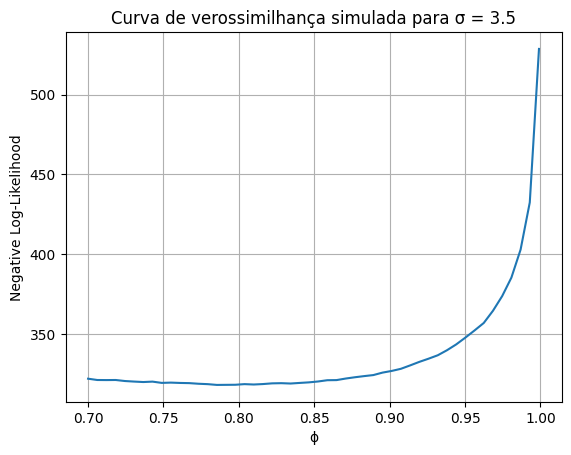

In [164]:
ϕ_grid = np.linspace(0.7, 0.999, 50)
losses = [neg_log_likelihood([ϕ, 3.5], y_true, N=3000, R=3) for ϕ in ϕ_grid]

plt.plot(ϕ_grid, losses)
plt.xlabel("ϕ")
plt.ylabel("Negative Log-Likelihood")
plt.title("Curva de verossimilhança simulada para σ = 3.5")
plt.grid(True)
plt.show()

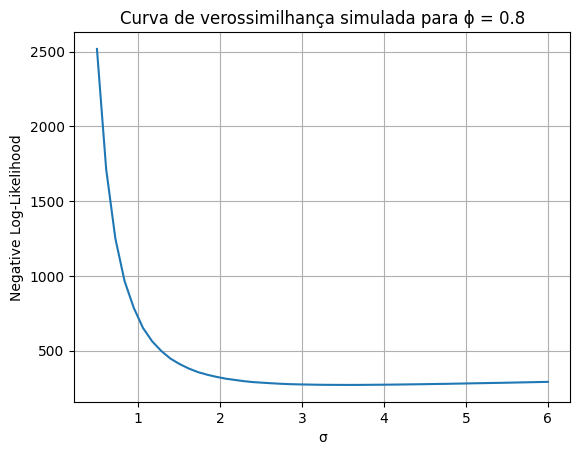

In [180]:
sigma_grid = np.linspace(0.5, 6.0, 50)
losses = [neg_log_likelihood([0.2, sigma], y_true, N=3000, R=3) for sigma in sigma_grid]

plt.plot(sigma_grid, losses)
plt.xlabel("σ")
plt.ylabel("Negative Log-Likelihood")
plt.title("Curva de verossimilhança simulada para ϕ = 0.8")
plt.grid(True)
plt.show()

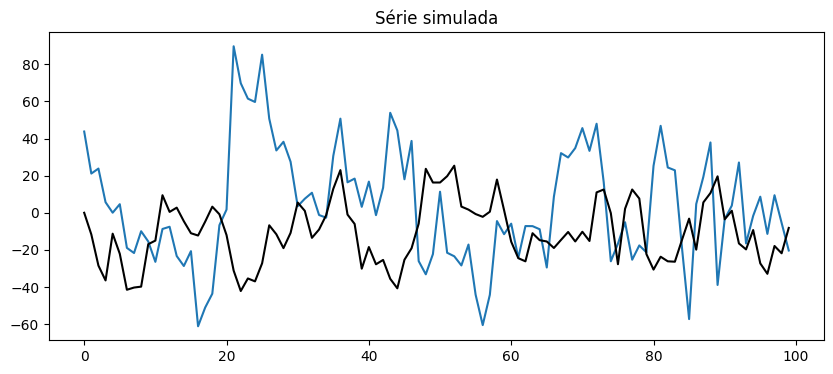

In [54]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(np.arange(T), yt[0,:], label='Simulação')
ax.plot(np.arange(T), y_true, label='Série real', color='black')
ax.set_title('Série simulada')
plt.show()

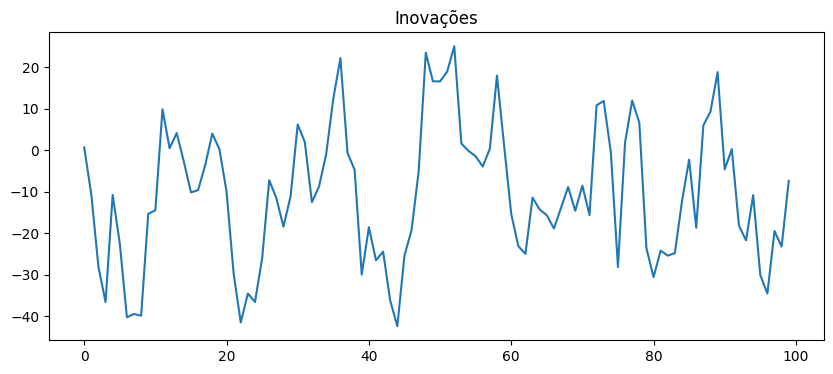

In [65]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(np.arange(T), vt, label='Simulação')
ax.set_title('Inovações')
plt.show()

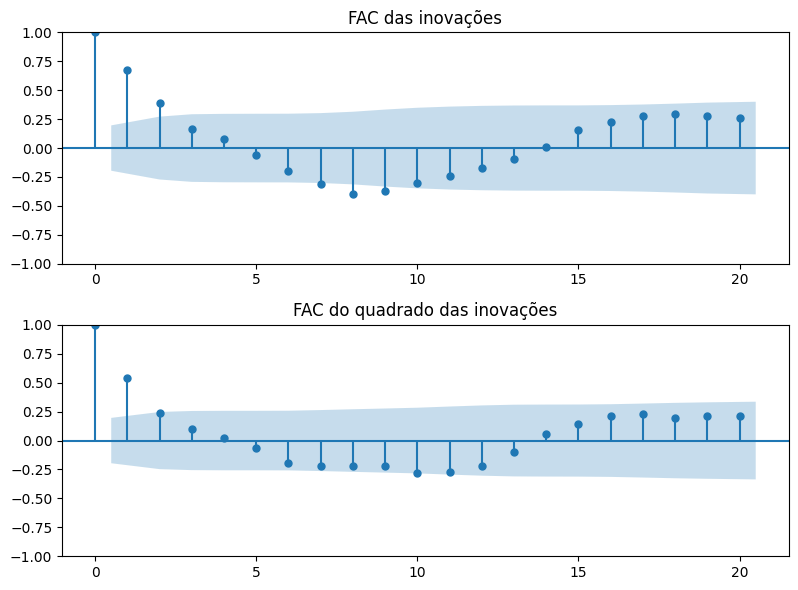

In [67]:
fig, ax = plt.subplots(2, figsize=(8,6))
plot_acf(vt, ax=ax[0], title='FAC das inovações')
plot_acf(vt**2, ax=ax[1], title='FAC do quadrado das inovações')
fig.tight_layout()
plt.show()

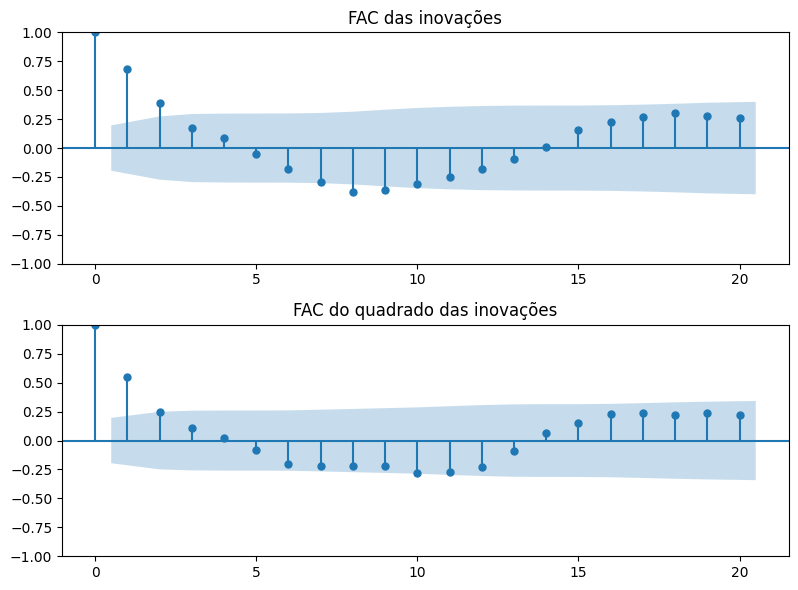

In [68]:
fig, ax = plt.subplots(2, figsize=(8,6))
plot_acf(y_true, ax=ax[0], title='FAC das inovações')
plot_acf(y_true**2, ax=ax[1], title='FAC do quadrado das inovações')
fig.tight_layout()
plt.show()